# Machine Learning Pipeline for Queen Bee Acoustic Monitoring

# Import Library & Setup Environment

In [1]:
import os
import torch
import torchaudio
import pandas as pd
import numpy as np
import random
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import librosa

from torch.amp import GradScaler, autocast
from dotenv import load_dotenv
from huggingface_hub import login
from transformers import ASTFeatureExtractor, ASTForAudioClassification
from sklearn.model_selection import StratifiedGroupKFold
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
from sklearn.metrics import confusion_matrix, classification_report, recall_score, f1_score

In [2]:
load_dotenv()
hf_token = os.getenv("HF_TOKEN")
login(token=hf_token)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [3]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Run Model on: {DEVICE}")

Run Model on: cuda


In [4]:
RAW_AUDIO_DIR = 'dataset'
LABEL_CSV = 'dataset/state_labels.csv'

In [5]:
WINDOW_SEC = 5.0

df_labels = pd.read_csv(LABEL_CSV)
new_records = []

print("Finding all audio files in folder")
audio_files_map = {}
for root, dirs, files in os.walk(RAW_AUDIO_DIR):
    for file in files:
        if file.endswith('.wav') or file.endswith('.mp3'):
            base_name = os.path.splitext(file)[0]
            audio_files_map[base_name] = os.path.join(root, file)

print(f"Find all {len(audio_files_map)} File (Ready for matching with CSV)")

print("Start slicing audio file")
for _, row in tqdm(df_labels.iterrows(), total=len(df_labels)):
    sample_name = str(row['sample_name']).strip()
    label = str(row['label']).strip().lower()

    if label not in ['active', 'missing queen']: continue
    
    if sample_name not in audio_files_map:
        continue 
        
    file_path = audio_files_map[sample_name]
        
    try:
        info = torchaudio.info(file_path)
        sr = info.sample_rate
        total_frames = info.num_frames
        chunk_frames = int(sr * WINDOW_SEC)
        
        for start_frame in range(0, total_frames, chunk_frames):
            end_frame = start_frame + chunk_frames
            if end_frame > total_frames: break # ทิ้งเศษท้ายคลิป
            
            numeric_label = 0 if label == 'active' else 1
            new_records.append({
                'audio_path': file_path,
                'hive_id': sample_name.split('_')[0], 
                'start_frame': start_frame,
                'num_frames': chunk_frames,
                'label': numeric_label
            })

    except Exception as e:
        pass

df_processed = pd.DataFrame(new_records)
df_processed.to_csv('virtual_hive_state_dataset.csv', index=False)
print(f"Finish slicing audio files, received {len(df_processed)} Files")

Finding all audio files in folder
Find all 576 File (Ready for matching with CSV)
Start slicing audio file


  0%|          | 0/573 [00:00<?, ?it/s]

Finish slicing audio files, received 67049 Files


In [6]:
TARGET_SR = 16000
feature_extractor = ASTFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")

class VirtualHiveStateDataset(Dataset):
    def __init__(self, df, augment=False):
        self.df = df.reset_index(drop=True)
        self.augment = augment
        self.resampler = torchaudio.transforms.Resample(orig_freq=22050, new_freq=TARGET_SR)

    def __len__(self): return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        start_frame = int(row['start_frame'])
        num_frames = int(row['num_frames'])

        try:
            waveform, sr = torchaudio.load(row['audio_path'], frame_offset=start_frame, num_frames=num_frames)

            if sr != TARGET_SR:
                waveform = self.resampler(waveform)
            # บังคับ Mono
            if waveform.shape[0] > 1:
                waveform = torch.mean(waveform, dim=0, keepdim=True)

            if self.augment:
                waveform = waveform * random.uniform(0.7, 1.2)
                if random.random() < 0.4:
                    noise = torch.randn_like(waveform) * random.uniform(0.001, 0.01)
                    waveform += noise

            waveform_np = waveform.numpy()[0]

        except Exception:
            waveform_np = np.zeros(int(TARGET_SR * 5.0))

        inputs = feature_extractor(waveform_np, sampling_rate=TARGET_SR, return_tensors="pt")
        ast_tensor = inputs.input_values[0]
        label = torch.tensor(row['label'], dtype=torch.long)
        return ast_tensor, label

df_all = pd.read_csv('virtual_hive_state_dataset.csv')

sgkf = StratifiedGroupKFold(n_splits=5)

for train_idx, test_idx in sgkf.split(df_all, df_all['label'], groups=df_all['audio_path']):
    df_train = df_all.iloc[train_idx]
    df_test = df_all.iloc[test_idx]
    break

BATCH_SIZE = 4
print(f"Data is ready Train: {len(df_train)} | Test: {len(df_test)}")

Data is ready Train: 53583 | Test: 13466


In [7]:
class ModernHiveASTModel(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.ast = ASTForAudioClassification.from_pretrained(
            "MIT/ast-finetuned-audioset-10-10-0.4593",
            ignore_mismatched_sizes=True,
            num_labels=num_classes
        )
        self.ast.gradient_checkpointing_enable()
        for param in self.ast.audio_spectrogram_transformer.parameters():
            param.requires_grad = False

    def forward(self, x):
        outputs = self.ast(x)
        return outputs.logits

if __name__ == '__main__':
    
    model = ModernHiveASTModel(num_classes=2).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=5e-5, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

    print("Built AI Model leaw :)")

    EPOCHS = 10
    best_val_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_recall': [], 'val_f1': []}
    print("Train Set:\n", df_train['label'].value_counts())
    print("Test Set:\n", df_test['label'].value_counts())
    train_loader = DataLoader(
        VirtualHiveStateDataset(df_train, augment=True), 
        batch_size=BATCH_SIZE, # สมมติว่าตั้ง BATCH_SIZE=4 ไว้แล้ว
        shuffle=True, 
        num_workers=0,
        pin_memory=True
    )

    test_loader = DataLoader(
        VirtualHiveStateDataset(df_test, augment=False), 
        batch_size=BATCH_SIZE, 
        shuffle=False, 
        num_workers=0, 
        pin_memory=True
    )
    
    print("Starting Training Modelll")
    torch.cuda.empty_cache()

    scaler = GradScaler('cuda')
    accumulation_steps = 8

    for epoch in range(EPOCHS):

        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        optimizer.zero_grad()

        train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
        for i, (inputs, labels) in enumerate(train_loop):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            with autocast('cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                # หารค่า loss เพื่อให้ผลรวมมันเท่ากับตอนที่เราใช้ Batch Size ใหญ่ๆ จริงๆ
                loss = loss / accumulation_steps 
                
            # คำนวณความผิดพลาดสะสมไว้
            scaler.scale(loss).backward()

            # 🎯 พอสะสมครบ 8 รอบ (หรือรอบสุดท้าย) ค่อยอัปเดตน้ำหนักการ์ดจอทีเดียว!
            if (i + 1) % accumulation_steps == 0 or (i + 1) == len(train_loader):
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad() # อัปเดตเสร็จค่อยล้างค่าทิ้ง

            train_loss += (loss.item() * accumulation_steps) * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
            
            current_train_acc = (train_correct / train_total) * 100
            train_loop.set_postfix(loss=(loss.item() * accumulation_steps), acc=f"{current_train_acc:.2f}%")
            
        train_loss = train_loss / len(train_loader.dataset)
        train_acc = (train_correct / train_total) * 100
        
        # ---------------- Validation (เหมือนเดิม) ----------------
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        all_val_preds = []
        all_val_labels = []
        
        val_loop = tqdm(test_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Test]")
        with torch.no_grad():
            for inputs, labels in val_loop:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                
                with autocast('cuda'): # ลดแรมตอน Test ด้วย
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
                
                all_val_preds.extend(predicted.cpu().numpy())
                all_val_labels.extend(labels.cpu().numpy())

                current_val_acc = (val_correct / val_total) * 100
                val_loop.set_postfix(loss=loss.item(), acc=f"{current_val_acc:.2f}%")
                
        val_loss = val_loss / len(test_loader.dataset)
        val_acc = (val_correct / val_total) * 100
        val_recall = recall_score(all_val_labels, all_val_preds, average='macro', zero_division=0)
        val_f1 = f1_score(all_val_labels, all_val_preds, average='macro', zero_division=0)

        scheduler.step(val_acc)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_recall'].append(val_recall)
        history['val_f1'].append(val_f1)
        
        print(f"Epoch {epoch+1}:")
        print(f"   Train => Loss: {train_loss:.4f} | Acc: {train_acc:.2f}%")
        print(f"   Val   => Loss: {val_loss:.4f} | Acc: {val_acc:.2f}% | Recall: {val_recall:.4f} | F1: {val_f1:.4f}\n")
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_hive_state_model.pth') 
            print(f"Saved NEW Best Model! (Val acc: {best_val_acc:.2f}%)\n")

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                         
------------------------+----------+-----------------------------------------------------------------------------------------
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527]) vs model:torch.Size([2])          
classifier.dense.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527, 768]) vs model:torch.Size([2, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Built AI Model leaw :)
Train Set:
 label
0    26907
1    26676
Name: count, dtype: int64
Test Set:
 label
0    6776
1    6690
Name: count, dtype: int64
Starting Training Modelll


Epoch 1/10 [Train]:   0%|          | 0/13396 [00:00<?, ?it/s]

Epoch 1/10 [Test]:   0%|          | 0/3367 [00:00<?, ?it/s]

...

Epoch 9/10 [Test]:   0%|          | 0/3367 [00:00<?, ?it/s]

Epoch 9:
   Train => Loss: 0.3456 | Acc: 86.53%
   Val   => Loss: 0.1971 | Acc: 94.54% | Recall: 0.9454 | F1: 0.9454



Epoch 10/10 [Train]:   0%|          | 0/13396 [00:00<?, ?it/s]

Epoch 10/10 [Test]:   0%|          | 0/3367 [00:00<?, ?it/s]

Epoch 10:
   Train => Loss: 0.3468 | Acc: 86.51%
   Val   => Loss: 0.1982 | Acc: 94.64% | Recall: 0.9463 | F1: 0.9464

Saved NEW Best Model! (Val acc: 94.64%)



Last Evaluate

 Classification Report:
                   precision    recall  f1-score   support

       Active (0)       0.94      0.95      0.95      6776
Missing Queen (1)       0.95      0.94      0.95      6690

         accuracy                           0.95     13466
        macro avg       0.95      0.95      0.95     13466
     weighted avg       0.95      0.95      0.95     13466



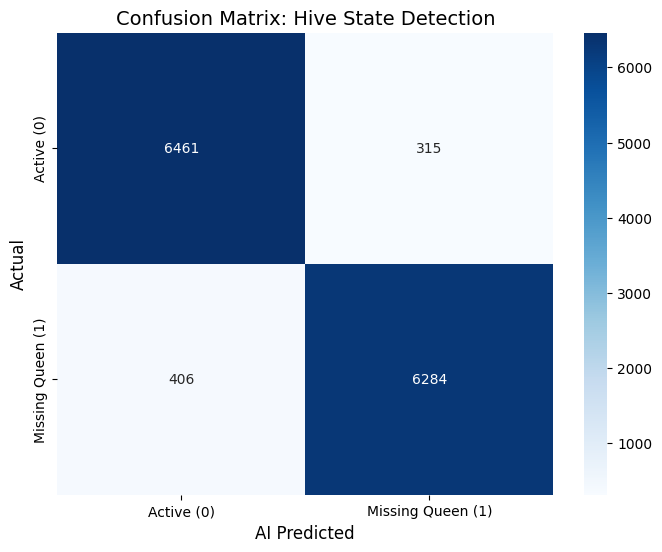

In [8]:
model.load_state_dict(torch.load('best_hive_state_model.pth'))
model.eval()

all_preds = []
all_labels = []

print("Last Evaluate")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

target_names = ['Active (0)', 'Missing Queen (1)']
print("\n Classification Report:")
print(classification_report(all_labels, all_preds, target_names=target_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix: Hive State Detection', fontsize=14)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('AI Predicted', fontsize=12)
plt.show()